In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
# == БЛОК 1: ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ==
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
missing_values_count = train.isnull().sum()
missing_values_count[0:]

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

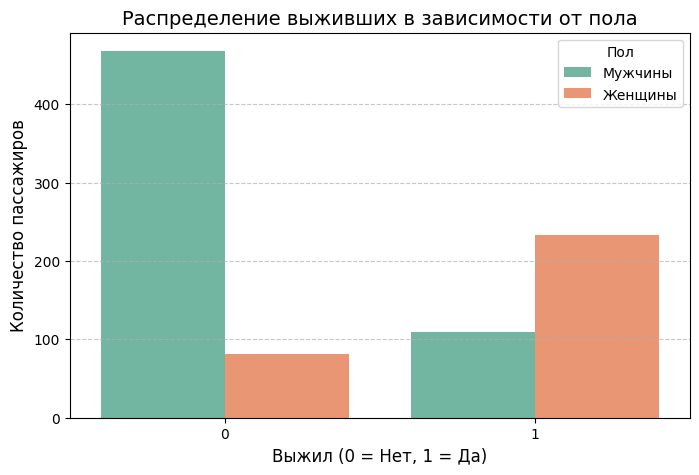

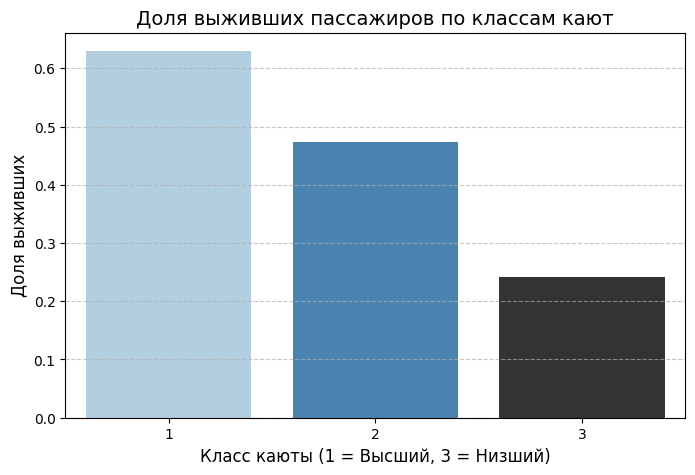

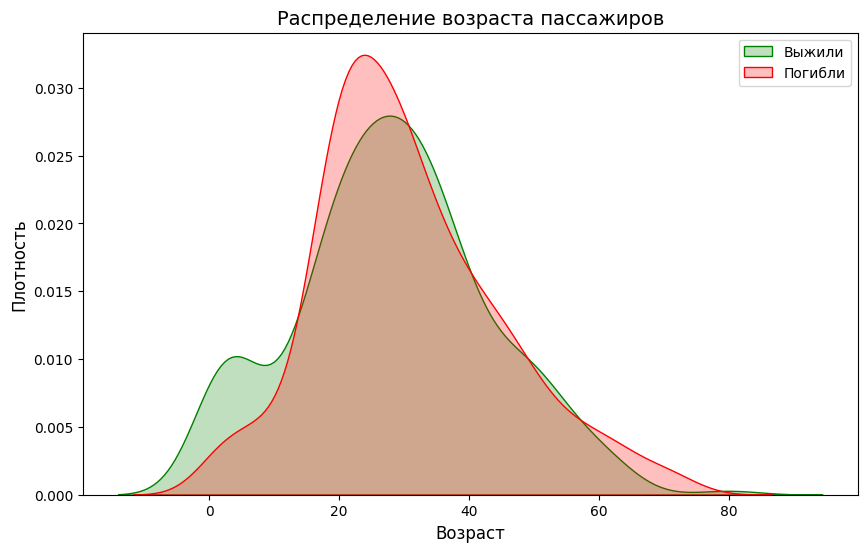

In [4]:
# == БЛОК 2: ВИЗУАЛИЗАЦИЯ ==
# График 1: Пол
plt.figure(figsize=(8, 5))
# Строим столбчатую диаграмму количества выживших/погибших в разрезе пола
sns.countplot(data=train, x='Survived', hue='Sex', palette='Set2')

plt.title('Распределение выживших в зависимости от пола', fontsize=14)
plt.xlabel('Выжил (0 = Нет, 1 = Да)', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.legend(title='Пол', labels=['Мужчины', 'Женщины'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# График 2: Класс
plt.figure(figsize=(8, 5))

sns.barplot(
    data=train, 
    x='Pclass', 
    y='Survived', 
    errorbar=None, 
    palette='Blues_d', 
    hue='Pclass', 
    legend=False
)

plt.title('Доля выживших пассажиров по классам кают', fontsize=14)
plt.xlabel('Класс каюты (1 = Высший, 3 = Низший)', fontsize=12)
plt.ylabel('Доля выживших', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# График 3: Возраст
plt.figure(figsize=(10, 6))
# Строим оценку плотности распределения (KDE) для возраста двух групп
sns.kdeplot(data=train[train['Survived'] == 1]['Age'], label='Выжили', fill=True, color='green')
sns.kdeplot(data=train[train['Survived'] == 0]['Age'], label='Погибли', fill=True, color='red')

plt.title('Распределение возраста пассажиров', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.show()

In [5]:
## Предобработка данных и инжиниринг признаков
# == БЛОК 3: ОЧИСТКА ДАННЫХ ==
def clean_data(df):
    df = df.copy()
    #заполняем пустоты
    df['Age'] = df['Age'].fillna(df.groupby(['Sex', 'Pclass'])['Age'].transform('median'))
    df['Embarked'] = df['Embarked'].fillna('S')
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    #текст в числа
    df['Sex'] = df['Sex'].replace({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].replace({'S': 0, 'C': 1, 'Q': 2})
    
    #выбираем признаки
    features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
    return df[features]

#готовим данные
X = clean_data(train)
y = train.Survived
X_test = clean_data(test)

/tmp/ipykernel_16/1832110412.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({'male': 0, 'female': 1})
/tmp/ipykernel_16/1832110412.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Embarked'] = df['Embarked'].replace({'S': 0, 'C': 1, 'Q': 2})
/tmp/ipykernel_16/1832110412.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavi

In [6]:
## Обучение модели и оценка качества
# == БЛОК 4: МОДЕЛИРОВАНИЕ ==
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=0)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(train_X, train_y)

preds = model.predict(val_X)
print(f"Точность модели на валидации: {accuracy_score(val_y, preds):.4f}")

# Финальное обучение на всех данных и сохранение
final_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
final_model.fit(X, y)
final_preds = final_model.predict(X_test)

output = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': final_preds})
output.to_csv('submission.csv', index=False)

Точность модели на валидации: 0.8341
